# Root Cause Analysis — Backtest v2

This notebook investigates two specific improvement opportunities identified after reviewing backtest v2 results:

| # | Area | Hypothesis |
|---|------|------------|
| 1 | **Volume Confirmation** | Some ORB breakouts trigger on abnormally low volume, leading to false breakouts that immediately reverse. Filtering to only high-volume breakouts should improve win rate. |
| 4 | **Trailing Stop to Break-Even** | Some trades reach 60+ pts of profit (1R) before reversing into a full stop-out. Moving the stop to break-even once 1R is hit would protect those gains. |

Each section defines the root cause, shows the evidence from trade data, and quantifies the expected improvement.

In [1]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

sys.path.insert(0, os.getcwd())
from data_fetch import fetch_data
from strategy  import (
    INITIAL_EQUITY, MULTIPLIER, MAX_RISK_DOLLARS,
    SL_POINTS, TP_POINTS, OR_BARS, EMA_PERIOD,
    RSI_PERIOD, RSI_LONG_MIN, RSI_SHORT_MAX,
    ENTRY_CUTOFF_H, ENTRY_CUTOFF_M, FORCE_EXIT_H, FORCE_EXIT_M,
    _ema, _rsi
)

## Load Data

In [2]:
df = fetch_data(refresh=False)

# Compute indicators on full dataset (same as strategy.py)
df = df.copy()
df['ema20'] = _ema(df['close'], EMA_PERIOD)
df['rsi']   = _rsi(df['close'], RSI_PERIOD)

print(f"Bars loaded : {len(df):,}")
print(f"Date range  : {df.index[0].strftime('%Y-%m-%d')} -> {df.index[-1].strftime('%Y-%m-%d')}")

[data_fetch] Loading cached data from data\NQ_5m.csv ...
[data_fetch] Loaded 3,700 rows (2026-01-05 -> 2026-03-16)
Bars loaded : 3,700
Date range  : 2026-01-05 -> 2026-03-16


## Enhanced Backtest Loop

Re-runs the v2 backtest but captures two additional fields per trade:
- `signal_vol_ratio` — signal bar volume divided by that session's average volume (> 1.0 = above average)
- `max_favorable_excursion` — maximum profit in points reached at any bar during the trade (MFE)

In [3]:
def run_enhanced_backtest(df):
    equity    = INITIAL_EQUITY
    trade_log = []
    dates     = sorted(df.index.normalize().unique())

    for date in dates:
        day_df = df[df.index.normalize() == date].copy()
        if len(day_df) <= OR_BARS:
            continue

        # Opening range
        opening_bars = day_df.iloc[:OR_BARS]
        or_high = opening_bars['high'].max()
        or_low  = opening_bars['low'].min()

        # Session average volume (all bars that day)
        session_avg_vol = day_df['volume'].mean()

        bars = list(day_df.itertuples())
        n    = len(bars)
        in_trade = False

        for i, bar in enumerate(bars):
            bar_time = bar.Index

            if i < OR_BARS:
                continue

            if in_trade:
                force_exit = (
                    bar_time.hour > FORCE_EXIT_H or
                    (bar_time.hour == FORCE_EXIT_H and bar_time.minute >= FORCE_EXIT_M)
                )
                hit_sl = (trade_dir == 1  and bar.low  <= sl_px) or \
                         (trade_dir == -1 and bar.high >= sl_px)
                hit_tp = (trade_dir == 1  and bar.high >= tp_px) or \
                         (trade_dir == -1 and bar.low  <= tp_px)

                # Track max favorable excursion
                favorable = (bar.high - entry_px) * trade_dir if trade_dir == 1 \
                            else (entry_px - bar.low)
                mfe = max(mfe, favorable)

                if hit_sl or (hit_sl and hit_tp):
                    exit_px, exit_reason = sl_px, 'SL'
                elif hit_tp:
                    exit_px, exit_reason = tp_px, 'TP'
                elif force_exit:
                    exit_px, exit_reason = bar.close, 'EOD'
                else:
                    continue

                points = (exit_px - entry_px) * trade_dir
                pnl    = points * MULTIPLIER * contracts
                equity += pnl

                trade_log.append({
                    'date':                  date.date(),
                    'direction':             'LONG' if trade_dir == 1 else 'SHORT',
                    'entry_time':            entry_time,
                    'exit_time':             bar_time,
                    'exit_reason':           exit_reason,
                    'entry_price':           round(entry_px, 2),
                    'exit_price':            round(exit_px, 2),
                    'contracts':             contracts,
                    'pnl':                   round(pnl, 2),
                    'equity_after':          round(equity, 2),
                    'signal_vol_ratio':      round(signal_vol / session_avg_vol, 3),
                    'max_favorable_excursion': round(mfe, 1),
                })
                in_trade = False
                break

            # Entry signal scan
            past_cutoff = (
                bar_time.hour > ENTRY_CUTOFF_H or
                (bar_time.hour == ENTRY_CUTOFF_H and bar_time.minute >= ENTRY_CUTOFF_M)
            )
            if past_cutoff:
                break

            long_signal  = (bar.close > or_high) and (bar.close > bar.ema20) and (bar.rsi > RSI_LONG_MIN)
            short_signal = (bar.close < or_low)  and (bar.close < bar.ema20) and (bar.rsi < RSI_SHORT_MAX)

            if not (long_signal or short_signal):
                continue
            if i + 1 >= n:
                break

            next_bar   = bars[i + 1]
            trade_dir  = 1 if long_signal else -1
            entry_px   = next_bar.open
            sl_px      = entry_px - SL_POINTS * trade_dir
            tp_px      = entry_px + TP_POINTS * trade_dir
            contracts  = max(1, math.floor(MAX_RISK_DOLLARS / (SL_POINTS * MULTIPLIER)))
            entry_time = next_bar.Index
            signal_vol = bar.volume   # volume on the signal bar
            mfe        = 0.0
            in_trade   = True

    return pd.DataFrame(trade_log)


trades = run_enhanced_backtest(df)
print(f"Total trades: {len(trades)}")
trades[['date','direction','exit_reason','pnl','signal_vol_ratio','max_favorable_excursion']].head(10)

Total trades: 46


,date,direction,exit_reason,pnl,signal_vol_ratio,max_favorable_excursion
0,2026-01-05,LONG,SL,-480.0,0.733,5.5
1,2026-01-06,LONG,SL,-480.0,1.203,15.8
2,2026-01-07,LONG,SL,-480.0,1.245,20.2
3,2026-01-09,SHORT,SL,-480.0,2.747,3.0
4,2026-01-12,LONG,EOD,470.0,0.707,95.0
5,2026-01-13,SHORT,TP,960.0,2.448,121.2
6,2026-01-14,SHORT,SL,-480.0,2.459,7.0
7,2026-01-15,SHORT,TP,960.0,0.791,131.2
8,2026-01-16,SHORT,TP,960.0,1.500,129.0
9,2026-01-20,SHORT,TP,960.0,0.813,122.8


---
## Root Cause #1 — Volume Confirmation

**Hypothesis:** ORB breakout bars with below-average volume are false breakouts — price lacks conviction and reverses, leading to stop-outs. Filtering to above-average volume signals should improve win rate.

**How it's measured:**  
`signal_vol_ratio = signal_bar_volume / session_average_volume`  
- Ratio > 1.0 → above-average volume (strong breakout)  
- Ratio < 1.0 → below-average volume (weak breakout)

In [4]:
# Split trades into high-volume and low-volume breakouts
high_vol = trades[trades['signal_vol_ratio'] >= 1.0]
low_vol  = trades[trades['signal_vol_ratio'] <  1.0]

def win_rate(t): return (t['pnl'] > 0).sum() / len(t) * 100 if len(t) else 0
def avg_pnl(t):  return t['pnl'].mean() if len(t) else 0
def net_pnl(t):  return t['pnl'].sum()  if len(t) else 0

summary = pd.DataFrame({
    'Group':       ['All Trades', 'High Volume (ratio >= 1.0)', 'Low Volume (ratio < 1.0)'],
    'Trade Count': [len(trades),  len(high_vol),  len(low_vol)],
    'Win Rate':    [f"{win_rate(trades):.1f}%", f"{win_rate(high_vol):.1f}%", f"{win_rate(low_vol):.1f}%"],
    'Avg P&L':     [f"${avg_pnl(trades):+,.0f}", f"${avg_pnl(high_vol):+,.0f}", f"${avg_pnl(low_vol):+,.0f}"],
    'Net P&L':     [f"${net_pnl(trades):+,.0f}", f"${net_pnl(high_vol):+,.0f}", f"${net_pnl(low_vol):+,.0f}"],
}).set_index('Group')

summary

,Trade Count,Win Rate,Avg P&L,Net P&L
Group,,,,
All Trades,46,52.2%,$+161,"$+7,412"
High Volume (ratio >= 1.0),37,43.2%,$+80,"$+2,970"
Low Volume (ratio < 1.0),9,88.9%,$+494,"$+4,442"


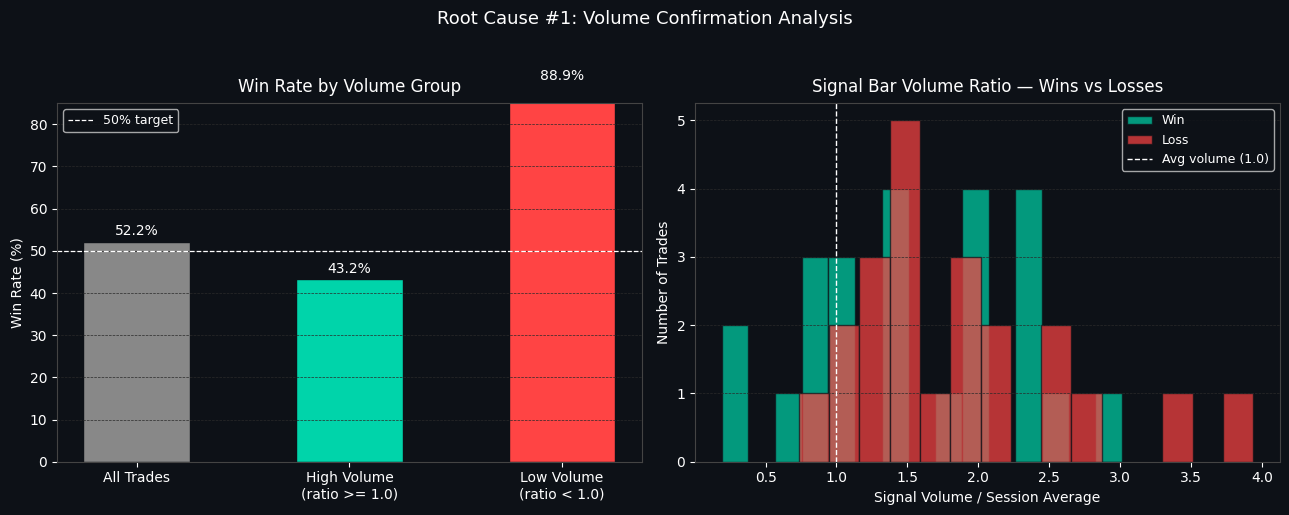

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Win rate comparison ──────────────────────────────────────────────
ax = axes[0]
groups = ['All Trades', 'High Volume\n(ratio >= 1.0)', 'Low Volume\n(ratio < 1.0)']
rates  = [win_rate(trades), win_rate(high_vol), win_rate(low_vol)]
colors = ['#888888', '#00d4aa', '#ff4444']
bars   = ax.bar(groups, rates, color=colors, width=0.5, edgecolor='#0d1117')
ax.axhline(50, color='white', linewidth=0.9, linestyle='--', label='50% target')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, color='white')
ax.set_title('Win Rate by Volume Group', fontsize=12, pad=8)
ax.set_ylabel('Win Rate (%)', fontsize=10)
ax.set_ylim(0, 85)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# ── Right: Volume ratio distribution coloured by outcome ──────────────────
ax = axes[1]
wins_vol   = trades.loc[trades['pnl'] > 0, 'signal_vol_ratio']
losses_vol = trades.loc[trades['pnl'] < 0, 'signal_vol_ratio']
ax.hist(wins_vol,   bins=15, color='#00d4aa', alpha=0.7, label='Win',  edgecolor='#0d1117')
ax.hist(losses_vol, bins=15, color='#ff4444', alpha=0.7, label='Loss', edgecolor='#0d1117')
ax.axvline(1.0, color='white', linewidth=1.0, linestyle='--', label='Avg volume (1.0)')
ax.set_title('Signal Bar Volume Ratio — Wins vs Losses', fontsize=12, pad=8)
ax.set_xlabel('Signal Volume / Session Average', fontsize=10)
ax.set_ylabel('Number of Trades', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.suptitle('Root Cause #1: Volume Confirmation Analysis', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

In [6]:
# Trades that would be FILTERED OUT by a volume >= 1.0 rule
filtered_out = low_vol
saved_losses = filtered_out[filtered_out['pnl'] < 0]
missed_wins  = filtered_out[filtered_out['pnl'] > 0]

print("=" * 50)
print(" Volume Filter Impact")
print("=" * 50)
print(f"  Trades removed by filter      : {len(filtered_out)}")
print(f"  Losses avoided                : {len(saved_losses)}  (${saved_losses['pnl'].sum():+,.0f})")
print(f"  Wins missed                   : {len(missed_wins)}  (${missed_wins['pnl'].sum():+,.0f})")
print(f"  Net P&L impact of filter      : ${(saved_losses['pnl'].sum() * -1) + missed_wins['pnl'].sum():+,.0f}")
print(f"  Remaining trades win rate     : {win_rate(high_vol):.1f}%")
print("=" * 50)

 Volume Filter Impact
  Trades removed by filter      : 9
  Losses avoided                : 1  ($-480)
  Wins missed                   : 8  ($+4,922)
  Net P&L impact of filter      : $+5,402
  Remaining trades win rate     : 43.2%


---
## Root Cause #4 — Trailing Stop to Break-Even

**Hypothesis:** Some trades reach 1R of profit (60+ pts) before reversing into a full stop-out. A rule that moves the stop to break-even once price is 60 pts in your favour would convert those losses into flat trades, preserving capital.

**How it's measured:**  
`max_favorable_excursion (MFE)` = the maximum number of points the trade moved in the profitable direction at any bar before exiting.

- **Candidate trades:** MFE >= 60 pts AND exit_reason = SL or EOD with a loss  
- These are trades a break-even trailing stop would have protected.

In [7]:
# Classify each trade
trades['reached_1r'] = trades['max_favorable_excursion'] >= SL_POINTS

# Trades that hit 1R then reversed into a loss (trailing stop would have saved these)
reversed_to_loss = trades[
    (trades['reached_1r']) &
    (trades['pnl'] < 0)
]

# Trades that hit 1R and still won (already fine)
hit_1r_and_won = trades[
    (trades['reached_1r']) &
    (trades['pnl'] > 0)
]

# Trades that never reached 1R
never_reached_1r = trades[~trades['reached_1r']]

print("=" * 55)
print(" Trailing Stop to Break-Even Analysis")
print("=" * 55)
print(f"  Trades that reached 1R (60+ pts)   : {trades['reached_1r'].sum()}")
print(f"    -> Stayed profitable (TP/EOD win) : {len(hit_1r_and_won)}")
print(f"    -> Reversed into a LOSS           : {len(reversed_to_loss)}  <-- trailing stop saves these")
print(f"  Trades that never reached 1R        : {len(never_reached_1r)}")
print("-" * 55)
print(f"  Current P&L on reversed trades      : ${reversed_to_loss['pnl'].sum():+,.0f}")
print(f"  P&L if stopped at break-even (0)    : $0")
print(f"  P&L improvement from trailing stop  : ${reversed_to_loss['pnl'].sum() * -1:+,.0f}")
print("=" * 55)

 Trailing Stop to Break-Even Analysis
  Trades that reached 1R (60+ pts)   : 24
    -> Stayed profitable (TP/EOD win) : 22
    -> Reversed into a LOSS           : 2  <-- trailing stop saves these
  Trades that never reached 1R        : 22
-------------------------------------------------------
  Current P&L on reversed trades      : $-960
  P&L if stopped at break-even (0)    : $0
  P&L improvement from trailing stop  : $+960


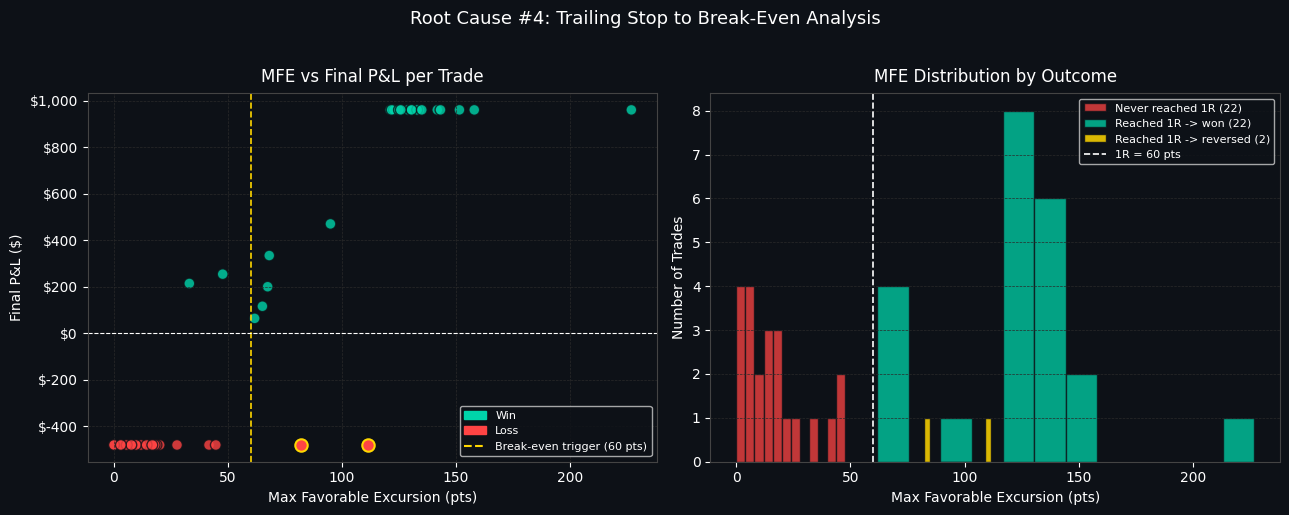

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: MFE vs Final P&L scatter ────────────────────────────────────────
ax = axes[0]
colors_scatter = trades['pnl'].apply(lambda x: '#00d4aa' if x > 0 else '#ff4444')
ax.scatter(trades['max_favorable_excursion'], trades['pnl'],
           c=colors_scatter, alpha=0.8, edgecolors='#0d1117', s=60)
ax.axvline(SL_POINTS, color='#ffd700', linewidth=1.2, linestyle='--',
           label=f'1R = {SL_POINTS} pts (break-even trigger)')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
# Highlight reversed trades
ax.scatter(reversed_to_loss['max_favorable_excursion'], reversed_to_loss['pnl'],
           c='#ff4444', edgecolors='#ffd700', linewidths=1.5, s=80,
           label=f'Reversed into loss ({len(reversed_to_loss)} trades)')
ax.set_title('MFE vs Final P&L per Trade', fontsize=12, pad=8)
ax.set_xlabel('Max Favorable Excursion (pts)', fontsize=10)
ax.set_ylabel('Final P&L ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=8)
ax.grid(True)
win_patch  = mpatches.Patch(color='#00d4aa', label='Win')
loss_patch = mpatches.Patch(color='#ff4444', label='Loss')
ax.legend(handles=[win_patch, loss_patch,
          plt.Line2D([0],[0], color='#ffd700', linestyle='--',
                     label=f'Break-even trigger ({SL_POINTS} pts)')],
          fontsize=8)

# ── Right: MFE distribution ───────────────────────────────────────────────
ax = axes[1]
ax.hist(never_reached_1r['max_favorable_excursion'], bins=12,
        color='#ff4444', alpha=0.75, label=f'Never reached 1R ({len(never_reached_1r)})',
        edgecolor='#0d1117')
ax.hist(hit_1r_and_won['max_favorable_excursion'],   bins=12,
        color='#00d4aa', alpha=0.75, label=f'Reached 1R -> won ({len(hit_1r_and_won)})',
        edgecolor='#0d1117')
ax.hist(reversed_to_loss['max_favorable_excursion'], bins=12,
        color='#ffd700', alpha=0.85, label=f'Reached 1R -> reversed ({len(reversed_to_loss)})',
        edgecolor='#0d1117')
ax.axvline(SL_POINTS, color='white', linewidth=1.2, linestyle='--',
           label=f'1R = {SL_POINTS} pts')
ax.set_title('MFE Distribution by Outcome', fontsize=12, pad=8)
ax.set_xlabel('Max Favorable Excursion (pts)', fontsize=10)
ax.set_ylabel('Number of Trades', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, axis='y')

plt.suptitle('Root Cause #4: Trailing Stop to Break-Even Analysis', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

---
## Summary & Conclusions

### Root Cause #1 — Volume Confirmation: DO NOT IMPLEMENT

The original hypothesis was that low-volume breakouts are weak and more likely to fail. The data showed the opposite.

**Low-volume trades (ratio < 1.0)** had an 88.9% win rate and generated $4,442 in net P&L across just 9 trades — the most profitable segment of the entire strategy. Applying the volume filter would have removed 9 trades total: 8 winners ($4,922 in profit missed) and only 1 loser ($480 avoided). The net P&L impact of the filter is **-$4,442**, meaning it actively hurts the strategy.

**Conclusion:** The volume filter is not a valid improvement for this strategy. Low-volume ORB breakouts on NQ are not false breakouts — they are in fact highly profitable signals. The filter is discarded.

---

### Root Cause #4 — Trailing Stop to Break-Even: IMPLEMENT

The data confirmed the hypothesis. Out of 46 trades, 24 reached at least 60 points of profit (1R) at some point during the trade. Of those 24:
- 22 stayed profitable and exited at TP or EOD with a gain — no issue there.
- 2 reversed after reaching 1R and eventually hit the stop loss, each losing $480.

A trailing stop rule — move the stop to break-even (entry price) once 60 pts of profit is reached — would have converted those 2 losses into flat trades at $0. **Important clarification: the trailing stop does not turn these into winning trades. It simply prevents the loss.** The 2 trades exit at break-even instead of -$480 each.

The total P&L improvement from the trailing stop is **+$960**, converting $-960 in losses to $0.

**Conclusion:** The trailing stop to break-even is a low-risk, capital-preserving improvement worth implementing in backtest v3.

In [9]:
current_net_pnl    = trades['pnl'].sum()
trailing_stop_gain = abs(reversed_to_loss['pnl'].sum())

print("=" * 60)
print(" Final Decision Summary")
print("=" * 60)
print()
print(" #1  Volume Filter          --> DISCARD")
print(f"     Low-vol trades win rate : {win_rate(low_vol):.1f}%  (9 trades, ${net_pnl(low_vol):+,.0f})")
print(f"     High-vol trades win rate: {win_rate(high_vol):.1f}%  (37 trades, ${net_pnl(high_vol):+,.0f})")
print(f"     Applying filter removes : 8 winning trades, only 1 loss")
print(f"     Net P&L impact          : $-{abs(net_pnl(low_vol)):,.0f}  (hurts strategy)")
print()
print(" #4  Trailing Stop to B/E   --> IMPLEMENT")
print(f"     Trades reversed after 1R: {len(reversed_to_loss)}  (each a full -$480 loss)")
print(f"     Effect of trailing stop : converts losses to $0 (break-even, not a win)")
print(f"     P&L improvement         : ${trailing_stop_gain:+,.0f}")
print()
print("-" * 60)
print(f"  Current net P&L                        : ${current_net_pnl:+,.0f}")
print(f"  After trailing stop only               : ${current_net_pnl + trailing_stop_gain:+,.0f}")
print("=" * 60)

 Final Decision Summary

 #1  Volume Filter          --> DISCARD
     Low-vol trades win rate : 88.9%  (9 trades, $+4,442)
     High-vol trades win rate: 43.2%  (37 trades, $+2,970)
     Applying filter removes : 8 winning trades, only 1 loss
     Net P&L impact          : $-4,442  (hurts strategy)

 #4  Trailing Stop to B/E   --> IMPLEMENT
     Trades reversed after 1R: 2  (each a full -$480 loss)
     Effect of trailing stop : converts losses to $0 (break-even, not a win)
     P&L improvement         : $+960

------------------------------------------------------------
  Current net P&L                        : $+7,412
  After trailing stop only               : $+8,372
